In [1]:
import igl
import scipy as sp
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jrandom
import jax.nn as nn
import jax.lax as lax
import jax.random as jrandom
import jax.nn as nn
import jax.lax as lax
import os
import jax.experimental.sparse as jsp
from scipy.sparse import diags, csr_matrix
from src.data.ToyData import *
from src.SDE import *
from src.SDESolver import *
import random
import trimesh
import matplotlib.pyplot as plt


In [2]:
def get_random_int():
    return random.randint(0, 1000000)
cwd = os.getcwd()
# v, f = igl.read_triangle_mesh(cwd + '/data/meshes/bunny.obj')
# K = igl.cotmatrix(v, f)
print(np.__version__)

1.26.4


JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


(1, 50, 50, 3)
(25, 49, 3)
(50, 49, 3)


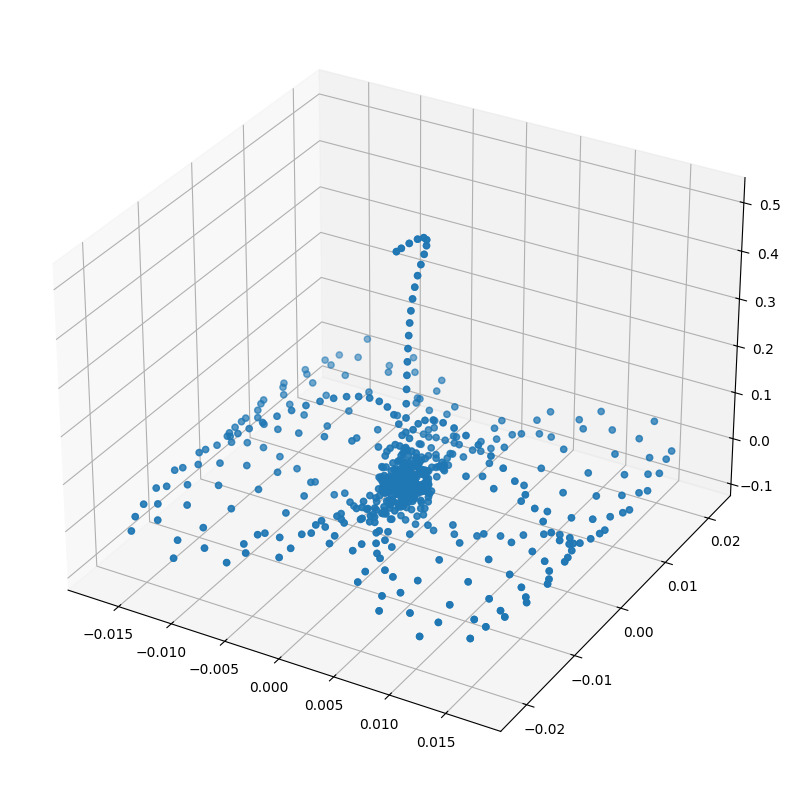

In [3]:
import s2fft
sphere_data_generator = ManifoldDataGenerator2D(grid_size=10, manifold_type="sphere", radius=0.5, seed = get_random_int())
sphere_data = sphere_data_generator.generate_data(50, 1)
print(sphere_data.shape)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
sphere_data= sphere_data.reshape(1, 50*50, 3)
sphere_data_sht = jax.vmap(lambda x: s2fft.forward(x, L = 25, sampling="dh", method="jax"), in_axes=(2))(sphere_data)

sphere_data_sht = jnp.transpose(sphere_data_sht, (1, 2, 0))
print(sphere_data_sht.shape)
sphere_data_sht_inv = jax.vmap(lambda x: s2fft.inverse(x, L = 25, sampling="dh", method="jax"), in_axes=(2))(sphere_data_sht)
sphere_data_sht_inv = jnp.transpose(sphere_data_sht_inv, (1, 2, 0))
sphere_data_sht_inv = jnp.real(sphere_data_sht_inv)
print(sphere_data_sht_inv.shape)
ax.scatter(sphere_data_sht_inv[:,:,0], sphere_data_sht_inv[:,:,1], sphere_data_sht_inv[:,:,2])
plt.show()



In [4]:

# # M = igl.massmatrix(v, f, igl.MASSMATRIX_TYPE_VORONOI)

# # m_inv = 1.0 / M.diagonal()
# # M_inv = diags(m_inv, format="csr")

# # L = -M_inv @ K

# sphere_data_generator = ManifoldDataGenerator(grid_num=10, manifold_type="sphere", seed = get_random_int())
# sphere_data_generator.generate_data(100, 1)
# sphere_v, sphere_f = sphere_data_generator.generate_data(100, 1)

# sde_3d = Kunita_Flow_SDE_3D_Eulerian(k_alpha=1.0, k_sigma=1.0, grid_num=25, grid_range=[-1,1], x0=sphere_v[0])
# sde_solver = EulerMaruyama.from_sde(sde_3d, 0.01, 1.0, 3, None,debug_mode=False)
# xs,_ = sde_solver.solve(sphere_v[0], rng_key=jrandom.PRNGKey(get_random_int()))
# print(xs.shape)

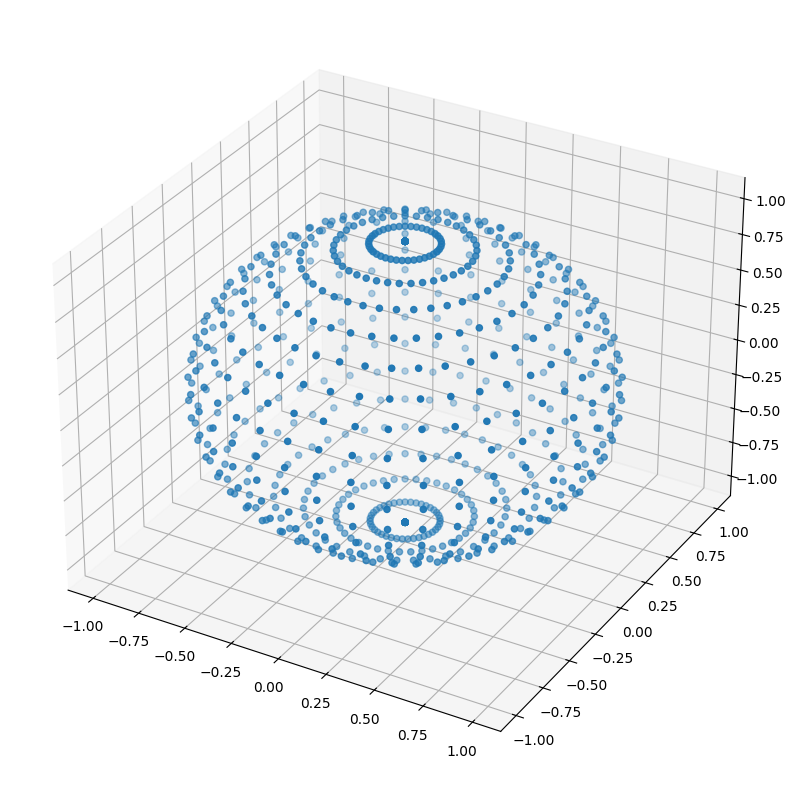

In [5]:
from src.data.ToyData import *
L = 20
data_generator = S2ManifoldDataGenerator(L=L, sampling="mw", manifold_type="sphere", seed=get_random_int())
data = data_generator.generate_data(20, 1)
data = data[0]
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:,:,0], data[:,:,1], data[:,:,2])
plt.show()


In [11]:
import s2fft
import numpy as np
print(data.shape)
# data_sht = jax.vmap(s2fft.forward, in_axes=(2, None))(data, data_generator.L, sampling=data_generator.sampling, method="jax")
# data_sht = []
# for i in range(data.shape[2]):
#     data_sht.append(s2fft.forward(data[:,:,i], data_generator.L, sampling=data_generator.sampling, method="jax"))
# data_sht = jnp.stack(data_sht, axis=-1)
L = 15
x = np.array(data)
data_sht = jax.vmap(lambda x: s2fft.wigner.forward(x, L = L, N=2 * L - 1, reality=True, sampling=data_generator.sampling, method="jax"), in_axes=(2))(data)
data_sht = jnp.transpose(data_sht, (1, 2, 0))
print(data_sht.shape)
inv_data_sht = jax.vmap(lambda x: s2fft.wigner.inverse(x, L = L, N=2*L-1, reality=True, sampling=data_generator.sampling, method="jax"), in_axes=(2))(data_sht)
inv_data_sht = jnp.transpose(inv_data_sht, (1, 2, 0))
print(inv_data_sht[1,:,:])
inv_data_real = jnp.real(inv_data_sht)
print(inv_data_real.shape)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(inv_data_real[:,:,0], inv_data_real[:,:,1], inv_data_real[:,:,2])
plt.show()





(20, 39, 3)


Warning: Recursive transform may provide lower precision beyond N ~ 8